# O modelo:

* A opção será o LightGBM.
 
 
  1- Relações Não-Lineares. O risco de crédito raramente é linear. Por exemplo, o risco pode ser baixo para as rendas médias, mas disparar subitamente abaixo de um certo patamar.
 
 
  2- A base de dados possui muitas categorias e possiveis valos nulos. LightGBM lidam com isso de forma nativa e eficiente.
 
 
  3- Como o case pede a "probabilidade de inadimplência", esses modelos são ideais pois a função predict_proba() retorna exatamente um valor entre 0 e 1.


  4- Velocidade. Tomada de decisão em tempo real, o LightGBM costuma ser ligeiramente superior ao XGBoost por ser mais rápido no processamento e exigir menos memória, o que é fundamental para sistemas que precisam responder em milissegundos durante uma solicitação de empréstimo.

# Definição da variável target. FDP (First Payment Default).

  1- Ocorre quando a primeira parcela (numero_parcela == 1) não é paga até a data prevista ou ultrapassa um limite de tolerância de 15 dias

In [ ]:
import optuna
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cloudpickle

from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import os
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb

import os
import pandas as pd
from urllib.parse import urlparse

In [ ]:
import os
from pathlib import Path
from urllib.parse import urlparse, urlunparse

import pandas as pd

# Read Parquet from MinIO via s3fs (pandas + pyarrow). Avoids PySpark/JVM on Windows,
# which often fails here with Py4JError / WinError 10054 when the Spark driver JVM exits.


def _is_s3_uri(path_value: str) -> bool:
    return path_value.startswith("s3://")


def _resolve_minio_endpoint_url(raw: str | None) -> str | None:
    """Rewrite Docker-only hostname `minio` to localhost (published host port, not container 9000)."""
    if not raw:
        return None
    parsed = urlparse(raw.strip())
    if parsed.hostname == "minio":
        host = os.getenv("MINIO_LOCAL_HOST", "127.0.0.1")
        port = int(os.getenv("MINIO_API_HOST_PORT", "9000"))
        netloc = f"{host}:{port}"
        return urlunparse((parsed.scheme, netloc, "", "", "", ""))
    return raw


def _load_dotenv_project():
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        env_file = d / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


_load_dotenv_project()

# Default matches docker-compose MinIO published on host port (MINIO_API_HOST_PORT, default 19000)
_raw_endpoint = (
    os.getenv("MLFLOW_S3_ENDPOINT_URL")
    or os.getenv("S3_ENDPOINT_URL")
    or "http://127.0.0.1:9000"
)
MINIO_ENDPOINT = _resolve_minio_endpoint_url(_raw_endpoint)
os.environ["MLFLOW_S3_ENDPOINT_URL"] = MINIO_ENDPOINT or _raw_endpoint
os.environ.setdefault("AWS_ENDPOINT_URL", MINIO_ENDPOINT or _raw_endpoint)

AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID", "minio123")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY", "minio123")

# fsspec / s3fs → boto3; path-style needed for MinIO
_PARQUET_STORAGE_OPTIONS = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {
        "endpoint_url": MINIO_ENDPOINT,
        "region_name": os.getenv("AWS_DEFAULT_REGION", "us-east-1"),
    },
    "config_kwargs": {"s3": {"addressing_style": "path"}},
}


def load_parquet_uri(uri: str) -> pd.DataFrame:
    if not _is_s3_uri(uri):
        raise ValueError(f"Expected s3:// URI, got {uri!r}")
    return pd.read_parquet(uri, storage_options=_PARQUET_STORAGE_OPTIONS)


DATA_PREFIX = os.getenv("MLFLOW_DATA_PREFIX", "s3://mlflow/data").rstrip("/")

historico_parcelas = load_parquet_uri(f"{DATA_PREFIX}/historico_parcelas.parquet")
historico_emprestimos = load_parquet_uri(f"{DATA_PREFIX}/historico_emprestimos.parquet")
base_cadastral = load_parquet_uri(f"{DATA_PREFIX}/base_cadastral.parquet")


In [ ]:
print(historico_parcelas.columns)
print(historico_emprestimos.columns)
print(base_cadastral.columns)

### FDP (First Payment Default), é quando o numero_parcela = 1 e passados 1 dia do vencimento

In [ ]:
import pandas as pd
import numpy as np

# 1. Garantir que as colunas são datetime
historico_parcelas['data_real_pagamento'] = pd.to_datetime(historico_parcelas['data_real_pagamento'], errors='coerce')
historico_parcelas['data_prevista_pagamento'] = pd.to_datetime(historico_parcelas['data_prevista_pagamento'], errors='coerce')

# 2. Identificar a primeira parcela
fpd_target = historico_parcelas[historico_parcelas['numero_parcela'] == 1].copy()

# 3. Calcular os dias de atraso
fpd_target['atraso_fpd'] = (fpd_target['data_real_pagamento'] - fpd_target['data_prevista_pagamento']).dt.days

# 4. Definir o Target FPD (Inadimplência na 1ª parcela)
# Definimos como 1 se atrasou > 15 dias OU se o valor é NaN (nunca pagou)
fpd_target['target_fpd'] = np.where(
    (fpd_target['atraso_fpd'] > 1) | (fpd_target['atraso_fpd'].isna()), 
    1, 0
)

# 5. Criar dataframe de treino (unindo com os dados do empréstimo)
df_train = pd.merge(
    historico_emprestimos, 
    fpd_target[['id_contrato', 'target_fpd']], 
    on='id_contrato', 
    how='inner'
)

print(f"Taxa de FirstPaymentDefault na base: {df_train['target_fpd'].mean():.2%}")

### EVER30 & OVER60

In [ ]:
import pandas as pd
import numpy as np

# Garantir conversão de datas
historico_parcelas['data_real_pagamento'] = pd.to_datetime(historico_parcelas['data_real_pagamento'], errors='coerce')
historico_parcelas['data_prevista_pagamento'] = pd.to_datetime(historico_parcelas['data_prevista_pagamento'], errors='coerce')

# Calcular o atraso individual de cada parcela
historico_parcelas['atraso'] = (historico_parcelas['data_real_pagamento'] - historico_parcelas['data_prevista_pagamento']).dt.days
historico_parcelas['atraso'] = historico_parcelas['atraso'].fillna(999) # Se não pagou, assumimos atraso crítico

# --- CALCULANDO EVER30MOB03 ---
# Filtramos as parcelas 1, 2 e 3
mob03 = historico_parcelas[historico_parcelas['numero_parcela'] <= 3]
ever30 = mob03.groupby('id_contrato')['atraso'].max() > 30
ever30 = ever30.astype(int).reset_index().rename(columns={'atraso': 'target_ever30mob03'})

# --- CALCULANDO OVER60MOB06 ---
# Filtramos as parcelas de 1 a 6
mob06 = historico_parcelas[historico_parcelas['numero_parcela'] <= 6]
# Somamos o atraso acumulado (atrasos positivos apenas)
over60 = mob06.groupby('id_contrato')['atraso'].apply(lambda x: x[x > 0].sum()) > 60
over60 = over60.astype(int).reset_index().rename(columns={'atraso': 'target_over60mob06'})

# --- UNINDO À BASE DE TREINO ---
df_targets = pd.merge(ever30, over60, on='id_contrato', how='outer').fillna(0)
df_final = pd.merge(df_train, df_targets, on='id_contrato', how='left')

In [ ]:
# --- PRINT NA TAXA DE INADIMPLÊNCIA ---

print("="*60)
print(f"{'RESUMO DAS TAXAS DE INADIMPLÊNCIA (BAD RATE)':^60}")
print("="*60)

# Cálculo das taxas
taxa_ever30 = df_final['target_ever30mob03'].mean()
taxa_over60 = df_final['target_over60mob06'].mean()

print(f"Taxa EVER30MOB03: {taxa_ever30:.2%} (Rigoroso - Foco em Fraude/Capacidade)")
print(f"Taxa OVER60MOB06: {taxa_over60:.2%} (Default Real - Foco em Perda Financeira)")
print("-"*60)

# Verificação de volume
total_contratos = len(df_final)
print(f"Total de contratos analisados: {total_contratos}")
print(f"Qtd de 'Bads' no EVER30: {df_final['target_ever30mob03'].sum()}")
print(f"Qtd de 'Bads' no OVER60: {df_final['target_over60mob06'].sum()}")
print("="*60)

In [13]:
# Unindo os dados do contrato (df_train) com o perfil do cliente (base_cadastral)
df_features = pd.merge(df_train, base_cadastral, on='id_cliente', how='left')

In [14]:
# --- 1. Financeiro ---
df_features['renda_mensal'] = df_features['renda_anual'] / 12
df_features['feat_comprometimento_renda'] = df_features['valor_parcela'] / df_features['renda_mensal']
df_features['feat_possui_carro'] = df_features['possui_carro'].map({'Y': 1, 'N': 0})
df_features['feat_possui_imovel'] = df_features['possui_imovel'].map({'Y': 1, 'N': 0})

# --- 2. Estabilidade ---
df_features['data_nascimento'] = pd.to_datetime(df_features['data_nascimento'])
df_features['data_decisao'] = pd.to_datetime(df_features['data_decisao'])
df_features['feat_idade'] = (df_features['data_decisao'] - df_features['data_nascimento']).dt.days // 365
df_features['feat_renda_per_capita'] = df_features['renda_anual'] / df_features['qtd_membros_familia']

# --- 3. Contrato e Contexto ---
# LTV: Se não houver valor do bem, consideramos o valor do crédito (LTV = 1)
df_features['feat_ltv'] = df_features['valor_credito'] / df_features['valor_bem'].replace(0, np.nan).fillna(df_features['valor_credito'])
df_features['feat_hora_pico_fraude'] = df_features['hora_solicitacao'].apply(lambda x: 1 if x < 7 or x > 21 else 0)

### LTV (Loan To Value)
* LTV Alto (ex: 95%): O cliente tem pouco "dinheiro próprio" no negócio. Se ele parar de pagar, o banco terá dificuldade em recuperar o valor total apenas vendendo o bem (devido à depreciação). É considerado alto risco.

* LTV Baixo (ex: 50%): O cliente deu uma entrada grande. Ele tem muito a perder se ficar inadimplente. É considerado baixo risco.

### DTI (Debt To Income)

* É o Índice de Comprometimento de Renda. Ele mede quanto da renda bruta mensal do cliente será "comida" pela parcela do empréstimo.
  
* Exemplo: Se um cliente ganha R$ 5.000 por mês e a parcela do empréstimo é de R$ 1.500, o DTI dele é de 30%.

In [15]:
features_list = [col for col in df_features.columns if col.startswith('feat_')]
X = df_features[features_list]
y = df_final['target_over60mob06']

print(f"Total de features criadas: {len(features_list)}")

Total de features criadas: 7


In [16]:
print(X.shape, y.shape)

(111704, 7) (111704,)


In [17]:
X.columns

Index(['feat_comprometimento_renda', 'feat_possui_carro', 'feat_possui_imovel',
       'feat_idade', 'feat_renda_per_capita', 'feat_ltv',
       'feat_hora_pico_fraude'],
      dtype='object')

[I 2026-05-25 21:42:03,183] A new study created in memory with name: no-name-e98763de-6a20-417b-9546-cee370ab884b
[I 2026-05-25 21:42:11,164] Trial 0 finished with value: 0.8221777322821165 and parameters: {'learning_rate': 0.017065573281248077, 'n_estimators': 142, 'num_leaves': 83, 'max_depth': 4}. Best is trial 0 with value: 0.8221777322821165.
[I 2026-05-25 21:42:15,079] Trial 1 finished with value: 0.8053239058190261 and parameters: {'learning_rate': 0.019069357909082145, 'n_estimators': 180, 'num_leaves': 57, 'max_depth': 9}. Best is trial 0 with value: 0.8221777322821165.
[I 2026-05-25 21:42:24,484] Trial 2 finished with value: 0.8101465422111221 and parameters: {'learning_rate': 0.013428222971070295, 'n_estimators': 447, 'num_leaves': 54, 'max_depth': 7}. Best is trial 0 with value: 0.8221777322821165.
[I 2026-05-25 21:42:34,176] Trial 3 finished with value: 0.8049874520706592 and parameters: {'learning_rate': 0.05048601745817518, 'n_estimators': 374, 'num_leaves': 53, 'max_dep


AUC Final: 0.8416


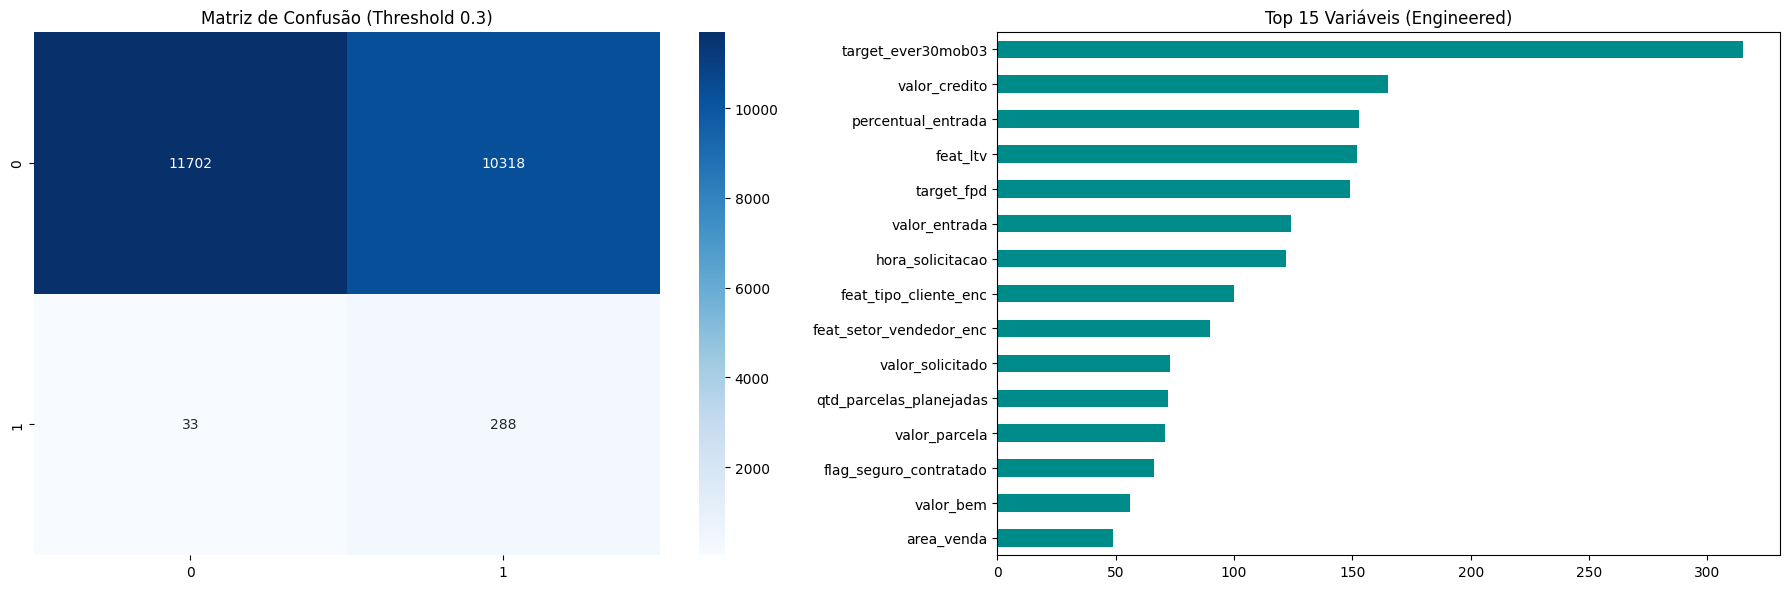

In [18]:
# ==========================================
# 1. PRÉ-PROCESSAMENTO: DEFINIÇÃO DE TARGETS
# ==========================================
# (Este bloco prepara a 'df_final' unindo as fontes de dados brutos)

def prepare_target_data(historico_parcelas, historico_emprestimos, base_cadastral):
    # Datas
    historico_parcelas['data_real_pagamento'] = pd.to_datetime(historico_parcelas['data_real_pagamento'], errors='coerce')
    historico_parcelas['data_prevista_pagamento'] = pd.to_datetime(historico_parcelas['data_prevista_pagamento'], errors='coerce')
    
    # Cálculo de atrasos
    historico_parcelas['atraso'] = (historico_parcelas['data_real_pagamento'] - historico_parcelas['data_prevista_pagamento']).dt.days
    historico_parcelas['atraso'] = historico_parcelas['atraso'].fillna(999)

    # MOB 06 - Target Principal (Over 60 days)
    mob06 = historico_parcelas[historico_parcelas['numero_parcela'] <= 6]
    over60 = mob06.groupby('id_contrato')['atraso'].apply(lambda x: x[x > 0].sum()) > 60
    over60 = over60.astype(int).reset_index().rename(columns={'atraso': 'target_over60mob06'})

    # Merge Final para Treino
    df_temp = pd.merge(historico_emprestimos, base_cadastral, on='id_cliente', how='left')
    df_final = pd.merge(df_temp, over60, on='id_contrato', how='inner')
    
    return df_final

# ==========================================
# 2. FEATURE ENGINEERING (DENTRO DO PIPELINE)
# ==========================================
class CreditFeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names=None):
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.target_cat_cols = [
            'tipo_contrato', 'status_contrato', 'tipo_pagamento', 
            'finalidade_emprestimo', 'tipo_cliente', 'tipo_portfolio', 
            'tipo_produto', 'categoria_bem', 'setor_vendedor', 'canal_venda'
        ]
        self.feature_names = feature_names

    def fit(self, X, y=None):
        actual_cat = [c for c in self.target_cat_cols if c in X.columns]
        if actual_cat:
            self.encoder.fit(X[actual_cat].fillna('Missing').astype(str))
        return self

    def transform(self, X):
        X_c = X.copy()

        # --- 1. Cadastral (renda_anual, qtd_membros_familia, possui_*) ---
        # Calcula derivadas quando as colunas existem (ex.: payload da API).
        # O artefato LGBM em produção espera 27 features (treino sem essas colunas na matriz).
        # As brutas e as feat_* cadastrais são removidas na limpeza final para manter o shape.
        if 'renda_anual' in X_c.columns:
            renda_mensal = X_c['renda_anual'] / 12
            if 'valor_parcela' in X_c.columns:
                X_c['feat_comprometimento_renda'] = X_c['valor_parcela'] / renda_mensal.replace(0, np.nan)
            if 'qtd_membros_familia' in X_c.columns:
                X_c['feat_renda_per_capita'] = X_c['renda_anual'] / X_c['qtd_membros_familia'].replace(0, np.nan)

        if 'possui_carro' in X_c.columns:
            X_c['feat_possui_carro'] = X_c['possui_carro'].map({'Y': 1, 'N': 0}).fillna(0)
        if 'possui_imovel' in X_c.columns:
            X_c['feat_possui_imovel'] = X_c['possui_imovel'].map({'Y': 1, 'N': 0}).fillna(0)

        # --- 2. Estabilidade (Datas) ---
        if 'data_nascimento' in X_c.columns and 'data_decisao' in X_c.columns:
            X_c['data_nascimento'] = pd.to_datetime(X_c['data_nascimento'], errors='coerce')
            X_c['data_decisao'] = pd.to_datetime(X_c['data_decisao'], errors='coerce')
            X_c['feat_idade'] = (X_c['data_decisao'] - X_c['data_nascimento']).dt.days // 365

        # --- 3. Contrato e Contexto ---
        if 'valor_credito' in X_c.columns and 'valor_bem' in X_c.columns:
            X_c['feat_ltv'] = X_c['valor_credito'] / X_c['valor_bem'].replace(0, np.nan).fillna(X_c['valor_credito'])
        
        if 'hora_solicitacao' in X_c.columns:
            X_c['feat_hora_pico_fraude'] = X_c['hora_solicitacao'].apply(lambda x: 1 if x < 7 or x > 21 else 0)

        # --- Encoding ---
        actual_cat = [c for c in self.target_cat_cols if c in X_c.columns]
        if actual_cat:
            encoded = self.encoder.transform(X_c[actual_cat].fillna('Missing').astype(str))
            for i, col in enumerate(actual_cat):
                X_c[f'feat_{col}_enc'] = encoded[:, i]

        # --- Limpeza Final ---
        cols_to_drop = [
            'id_cliente', 'id_contrato', 'data_decisao', 'data_liberacao',
            'data_primeiro_vencimento', 'data_ultimo_vencimento',
            'data_ultimo_vencimento_original', 'data_encerramento', 'data_nascimento',
            'renda_anual', 'qtd_membros_familia',
            'possui_carro', 'possui_imovel',
            'feat_comprometimento_renda', 'feat_renda_per_capita',
            'feat_possui_carro', 'feat_possui_imovel',
        ]
        X_final = X_c.drop(columns=[c for c in cols_to_drop if c in X_c.columns], errors='ignore')
        X_final = X_final.select_dtypes(include=[np.number])

        if self.feature_names is not None:
            for col in self.feature_names:
                if col not in X_final: X_final[col] = 0
            X_final = X_final[self.feature_names]

        return X_final

# ==========================================
# 3. TREINAMENTO E OPTUNA
# ==========================================
# Supondo que df_final foi gerada pela função prepare_target_data
X = df_final.drop(columns=['target_over60mob06'], errors='ignore')
y = df_final['target_over60mob06']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'is_unbalance': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
    }
    pipe = Pipeline([('fe', CreditFeatureEngineering()), ('lgb', lgb.LGBMClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=3, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

# ==========================================
# 4. MODELO FINAL E ARTEFATOS
# ==========================================
best_pipe = Pipeline([
    ('fe', CreditFeatureEngineering()),
    ('lgb', lgb.LGBMClassifier(**study.best_params, is_unbalance=True))
])

best_pipe.fit(X_train, y_train)

# ==========================================
# 5. AVALIAÇÃO E DASHBOARD
# ==========================================
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.3).astype(int)

print(f"\nAUC Final: {roc_auc_score(y_test, y_proba):.4f}")

# Plots
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Matriz de Confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão (Threshold 0.3)')

# Feature Importance
lgb_model = best_pipe.named_steps['lgb']
# Extrai nomes das colunas após o transform
feat_names = best_pipe.named_steps['fe'].transform(X_train.head(1)).columns
feat_imp = pd.Series(lgb_model.feature_importances_, index=feat_names).sort_values()

feat_imp.tail(15).plot(kind='barh', ax=ax[1], color='darkcyan')
ax[1].set_title('Top 15 Variáveis (Engineered)')

plt.tight_layout()
plt.show()

### Recomendação estratégica:

Pode-se priorizar Recall para defaulters, se o custo de um defaulter é muito maior do que a perda de lucro de um bom pagador. Logo a proposta Política de Crédito deve justificar o threshold baseado no estado atual do banco e seu apetite para risco. Se o banco está numa fase de crescimento, talvez usar 0.5 seja interessante, se em crise e há a necessidade imediata de cortar gastos, um threshold de 0.3

### Production grade
* persisting metrics and artifacts in MLFlow

In [28]:
os.environ["AWS_ACCESS_KEY_ID"] = "minio123"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minio123"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
os.environ["MLFLOW_S3_IGNORE_TLS"] = "true"

# ==========================================
# 1. CONFIGURAÇÃO DE CONEXÃO — MLflow LOCAL (localhost)
# ==========================================
# Notebook runs on the host against localhost:5000 (not docker-compose "mlflow:5000").
# Project .env sets admin/password1234 for Docker; override here so basic-auth matches
# your local MLflow server (admin123 / 12341234admin).
LOCAL_MLFLOW_URI = "http://localhost:5000"
LOCAL_MLFLOW_USER = os.getenv("MLFLOW_ADMIN_USERNAME", "admin123")
LOCAL_MLFLOW_PASSWORD = os.getenv("MLFLOW_ADMIN_PASSWORD", "12341234admin")

os.environ["MLFLOW_TRACKING_URI"] = LOCAL_MLFLOW_URI
os.environ["MLFLOW_TRACKING_USERNAME"] = LOCAL_MLFLOW_USER
os.environ["MLFLOW_TRACKING_PASSWORD"] = LOCAL_MLFLOW_PASSWORD
mlflow.set_tracking_uri(LOCAL_MLFLOW_URI)

# Define o experimento e captura o objeto para usar o ID depois
# set_experiment: usa o existente ou cria se não houver (create_experiment falha se já existir).
experiment_name = "Credit_Risk_Threshold_Analysis"
mlflow.set_experiment(experiment_name)
current_experiment = mlflow.get_experiment_by_name(experiment_name)

# ==========================================
# 2. RUN PAI: Treinamento e Global Assets
# ==========================================
with mlflow.start_run(run_name="LGBM_Full_Training") as parent_run:
    
    # Log de hiperparâmetros (ajuste conforme seu objeto study do optuna)
    # mlflow.log_params(study.best_params) 
    
    # Treino do Pipeline
    best_pipe = Pipeline([
        ('fe', CreditFeatureEngineering()),
        ('lgb', lgb.LGBMClassifier(is_unbalance=True)) # Exemplo simplificado
    ])
    best_pipe.fit(X_train, y_train)
    # Remove o wrapper sklearn set_output do transform (senão o cloudpickle pode travar/recursar em outro ambiente).
    import inspect
    import types
    _fe = best_pipe.named_steps["fe"]
    _fe.transform = types.MethodType(inspect.unwrap(_fe.transform), _fe)

    # Probabilidades globais
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    mlflow.log_metric("global_auc", auc_score)

    # Log do Modelo (IMPORTANTE: logar no pai para a API encontrar)
    # MLflow 3.x log_model always hits /logged-models (404 on older tracking servers).
    # save_model + log_artifacts uses classic run-artifact APIs (runs:/<run_id>/credit_model_pipeline_v1).
    import tempfile
    with tempfile.TemporaryDirectory() as _model_tmp:
        _model_path = os.path.join(_model_tmp, "credit_model_pipeline_v1")
        mlflow.sklearn.save_model(best_pipe, path=_model_path)
        mlflow.log_artifacts(_model_path, artifact_path="credit_model_pipeline_v1")
    with open("../prod/credit_model_pipeline.pkl", "wb") as f:
        cloudpickle.dump(best_pipe, f)

    # Gráfico de Importância (Global)
    plt.figure(figsize=(10, 8))
    feat_names = best_pipe.named_steps['fe'].transform(X_train.head(1)).columns
    feat_imp = pd.Series(best_pipe.named_steps['lgb'].feature_importances_, index=feat_names).sort_values()
    feat_imp.tail(15).plot(kind='barh', color='darkcyan')
    plt.title('Top 15 Engineered Features - Importância Global')
    plt.tight_layout()
    plt.savefig("global_feature_importance.png")
    mlflow.log_artifact("global_feature_importance.png")
    plt.close()

    # ==========================================
    # 3. CHILD RUNS: Loop de Thresholds
    # ==========================================
    thresholds = [0.3, 0.5, 0.9]
    
    for thr in thresholds:
        with mlflow.start_run(
            run_name=f"Assessment_Thr_{thr}", 
            nested=True,
            experiment_id=current_experiment.experiment_id
        ):
            y_pred = (y_proba >= thr).astype(int)
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            
            # --- Métricas Gerais ---
            mlflow.log_param("decision_threshold", thr)
            mlflow.log_metric("accuracy", report['accuracy'])
            
            # --- Métricas Classe 1 (Inadimplentes/Mau Pagadores) ---
            mlflow.log_metric("recall_class_1", report['1']['recall'])
            mlflow.log_metric("precision_class_1", report['1']['precision'])
            mlflow.log_metric("f1_class_1", report['1']['f1-score'])
            
            # --- Métricas Classe 0 (Bons Pagadores) ---
            # Adicionando estas para você ter a visão da "outra classe"
            mlflow.log_metric("recall_class_0", report['0']['recall'])
            mlflow.log_metric("precision_class_0", report['0']['precision'])
            mlflow.log_metric("f1_class_0", report['0']['f1-score'])


    print(f"Parent Run finalizada com sucesso!")
    print(f"ID para usar na API: {parent_run.info.run_id}")

2026/05/25 21:54:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Assessment_Thr_0.3 at: http://localhost:5000/#/experiments/1/runs/c728247ddaf3449c9d2a81b1910f2f9f
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run Assessment_Thr_0.5 at: http://localhost:5000/#/experiments/1/runs/182954968153456399701e3c5a068b25
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run Assessment_Thr_0.9 at: http://localhost:5000/#/experiments/1/runs/0cc0f1cafc2c465d8950c7ceb75ad22f
🧪 View experiment at: http://localhost:5000/#/experiments/1
Parent Run finalizada com sucesso!
ID para usar na API: 37527709e11c4406aa38b8d791a66056
🏃 View run LGBM_Full_Training at: http://localhost:5000/#/experiments/1/runs/37527709e11c4406aa38b8d791a66056
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [29]:
mlflow.end_run()